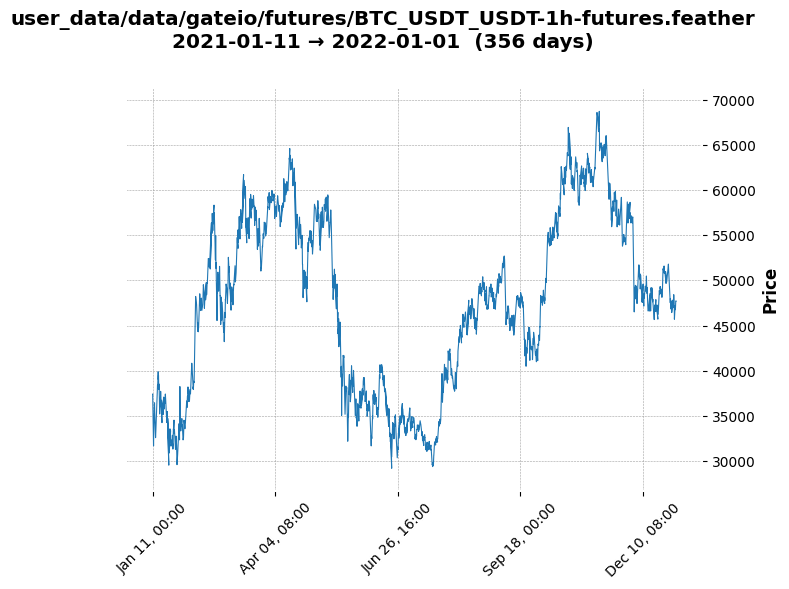

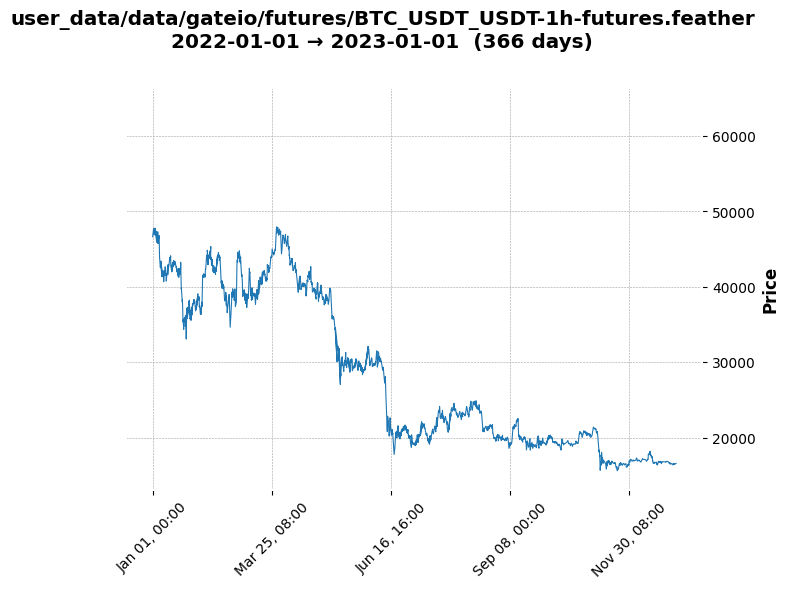

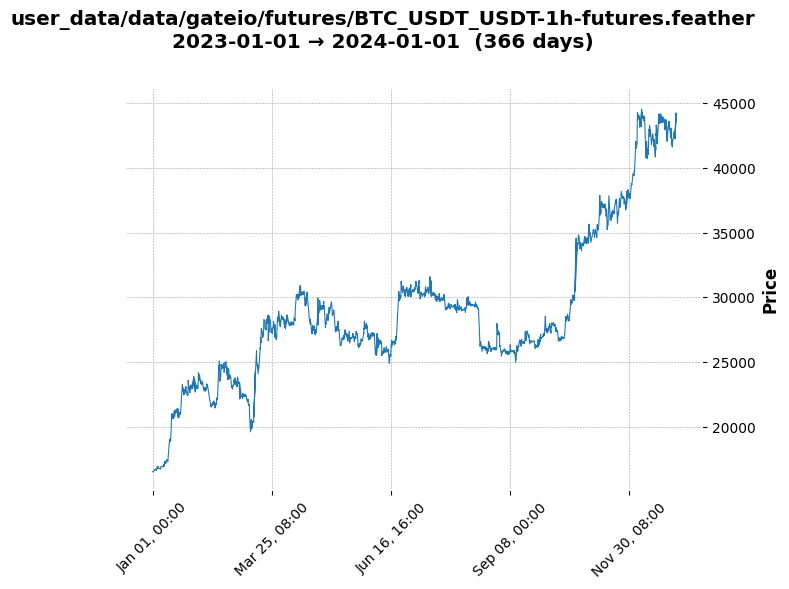

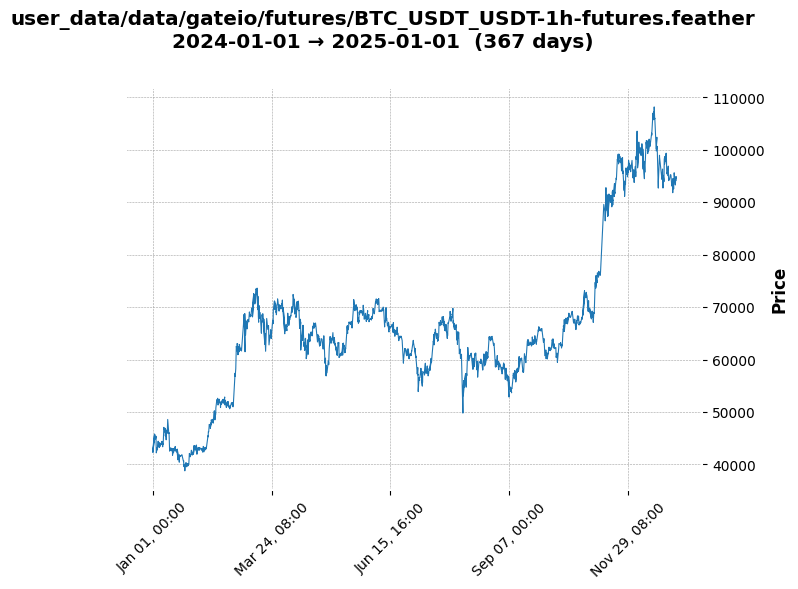

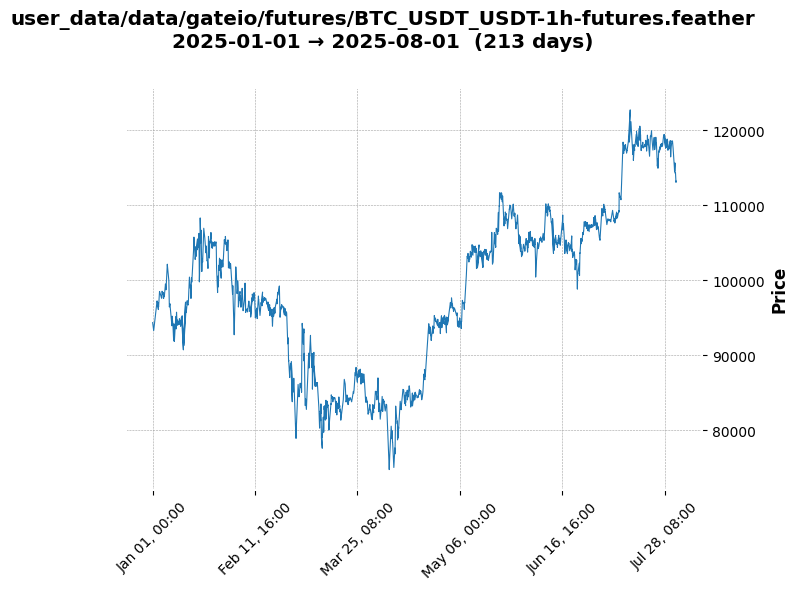

In [1]:
import pandas as pd
import mplfinance as mpf
filepath = "user_data/data/gateio/futures/BTC_USDT_USDT-1h-futures.feather"
def plot_freqtrade_candles_feather(start_date=None, end_date=None, last_n=None):
    """
    Plot candlestick chart from a Freqtrade feather candle file.
    
    Args:
        filepath (str): Path to the feather file (e.g. 'user_data/data/binance_futures/BTC_USDT-1h.feather')
        start_date (str): Start date 'YYYY-MM-DD' (optional)
        end_date (str): End date 'YYYY-MM-DD' (optional)
        last_n (int): If set, shows the last N candles instead of a date range
    """
    
    # Load feather file
    df = pd.read_feather(filepath)
    
    # Ensure 'date' is datetime and set as index
    df['date'] = pd.to_datetime(df['date'])
    df.set_index('date', inplace=True)
    
    # Filter by last_n or date range
    if last_n:
        df_plot = df.tail(last_n)
        title = f"{filepath} (last {last_n} candles)"
    elif start_date and end_date:
        # Convert YYYYMMDD -> YYYY-MM-DD
        start_str = f"{start_date[:4]}-{start_date[4:6]}-{start_date[6:]}"
        end_str   = f"{end_date[:4]}-{end_date[4:6]}-{end_date[6:]}"
        
        df_plot = df.loc[start_str:end_str]
        
        # Calculate number of unique days
        num_days = (df_plot.index[-1].normalize() - df_plot.index[0].normalize()).days + 1
        
        title = f"{filepath}\n{start_str} → {end_str}  ({num_days} days)"
    else:
        df_plot = df
        title = filepath
    
    # Auto-switch to line plot if too many candles
    plot_type = 'candle' if len(df_plot) <= 1000 else 'line'
    
    # Plot candlestick or line chart
    mpf.plot(
        df_plot,
        type=plot_type,
        style='charles',
        volume=(plot_type == 'candle'),
        title=title,
        warn_too_much_data=len(df_plot)+1
    )

# ✅ Example usage:
plot_freqtrade_candles_feather(start_date="20210111",end_date="20220101")
plot_freqtrade_candles_feather(start_date="20220101",end_date="20230101")
plot_freqtrade_candles_feather(start_date="20230101",end_date="20240101")
plot_freqtrade_candles_feather(start_date="20240101",end_date="20250101")
plot_freqtrade_candles_feather(start_date="20250101",end_date="20250801")
